# Climate Policy Archetypes - Consolidated Notebook with all my previous notebooks that now work with my new final datasets

runs three experiments:

1. **Snapshot Clustering** — What archetypes exist when we treat each country as a single averaged data point?
2. **Feature Set Comparison** — Do the clusters change when we remove economic indicators? (Finding over/underperformers)
3. **Temporal Trajectories** — How have countries *moved* through archetype space over time?

---
**Prerequisites:** Run `collecting.py` and `cleaning.py` first to generate:
- `data/processed/avg_cleaned_feature_matrix.csv`
- `data/processed/temporal_cleaned_feature_matrix.csv`

## 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import random, os, warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_AVAILABLE = True
    print("PyTorch available:", torch.__version__)
except ImportError:
    TORCH_AVAILABLE = False
    print("[WARNING] PyTorch not found — autoencoder sections will be skipped.")

# ── Reproducibility ──────────────────────────────────────────────────────────
# Setting seeds so that results are consistent across runs so I can test if changes to the code are improving things or not
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

os.makedirs('outputs', exist_ok=True)
print("Setup complete.")

PyTorch available: 2.10.0
Setup complete.


In [3]:
# ── Tweaks for experimentation ───────────────────────────────────────

K = 6                    # Number of clusters
AE_EPOCHS = 500          # Autoencoder training epochs
AE_LR     = 0.005        # Autoencoder learning rate

# Paths
PATH_AVG      = '../data/processed/avg_cleaned_feature_matrix.csv'
PATH_TEMPORAL = '../data/processed/temporal_cleaned_feature_matrix.csv'

# Economic columns — used when running policy-only experiments
ECON_COLS = ['log_gdp_pc', 'log_energy_pc', 'co2_emissions_per_gdp', 'nd_gain_score']

# ── Load data ─────────────────────────────────────────────────────────────────
df_avg = pd.read_csv(PATH_AVG)
print(f"Averaged dataset:  {df_avg.shape[0]} countries × {df_avg.shape[1]} columns")

df_temporal = pd.read_csv(PATH_TEMPORAL)
print(f"Temporal dataset:  {df_temporal.shape[0]} rows × {df_temporal.shape[1]} columns")

# Separate identifiers from features for each dataset
AVG_ID_COLS  = ['country_code', 'Name']
TEMP_ID_COLS = ['country_code', 'Name', 'year']

ids_avg  = df_avg[AVG_ID_COLS]
X_avg    = df_avg.drop(columns=AVG_ID_COLS)

ids_temp = df_temporal[TEMP_ID_COLS]
X_temp   = df_temporal.drop(columns=TEMP_ID_COLS)

print(f"\nFeature matrix (averaged):  {X_avg.shape}")
print(f"Feature matrix (temporal):  {X_temp.shape}")

Averaged dataset:  49 countries × 21 columns
Temporal dataset:  1029 rows × 22 columns

Feature matrix (averaged):  (49, 19)
Feature matrix (temporal):  (1029, 19)


---
## Part 1 — Snapshot Clustering (Averaged Data)

Each country is a single point representing its average across all years.
Comparing the three methods: **KMeans**, **Hierarchical**, and **DBSCAN**.

### 1a. KMeans — Finding the right K

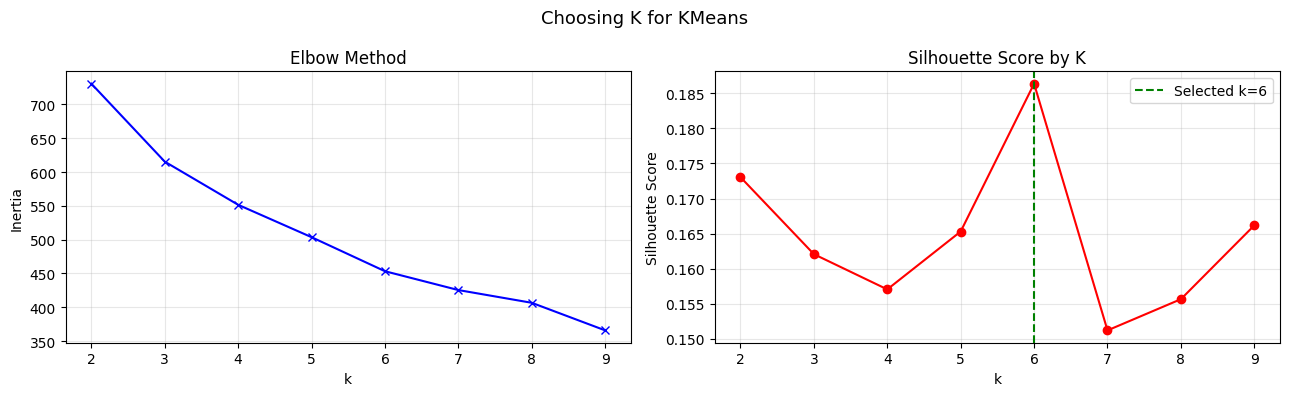

Best silhouette: k=6, score=0.1864


In [4]:
# Elbow plot 
inertia, sil_scores = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_avg)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_avg, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(K_range, inertia, 'bx-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_title('Silhouette Score by K')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.axvline(x=K, color='green', linestyle='--', label=f'Selected k={K}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Choosing K for KMeans', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/elbow.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Best silhouette: k={list(K_range)[np.argmax(sil_scores)]}, score={max(sil_scores):.4f}")

In [5]:
# Run KMeans with chosen K
km = KMeans(n_clusters=K, random_state=SEED, n_init=10)
km_labels = km.fit_predict(X_avg)
km_score  = silhouette_score(X_avg, km_labels)

df_avg['km_cluster'] = km_labels

print(f"KMeans Silhouette Score: {km_score:.4f}\n")
for i in range(K):
    countries = df_avg[df_avg['km_cluster'] == i]['Name'].sort_values().tolist()
    print(f"  Archetype {i} ({len(countries)}): {', '.join(countries)}")

KMeans Silhouette Score: 0.1864

  Archetype 0 (15): Austria, Belgium, France, Germany, Greece, Hungary, Italy, Latvia, Lithuania, Netherlands, Portugal, Slovakia, Spain, Switzerland, United Kingdom
  Archetype 1 (7): Brazil, India, Indonesia, Peru, Philippines, Turkey, Viet Nam
  Archetype 2 (7): Canada, Finland, Iceland, Ireland, Luxembourg, Norway, Sweden
  Archetype 3 (2): Denmark, New Zealand
  Archetype 4 (7): Argentina, Chile, Colombia, Japan, Mexico, Slovenia, South Africa
  Archetype 5 (11): Australia, China, Czech Republic, Estonia, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia, Singapore, United States


### 1b. Hierarchical Clustering

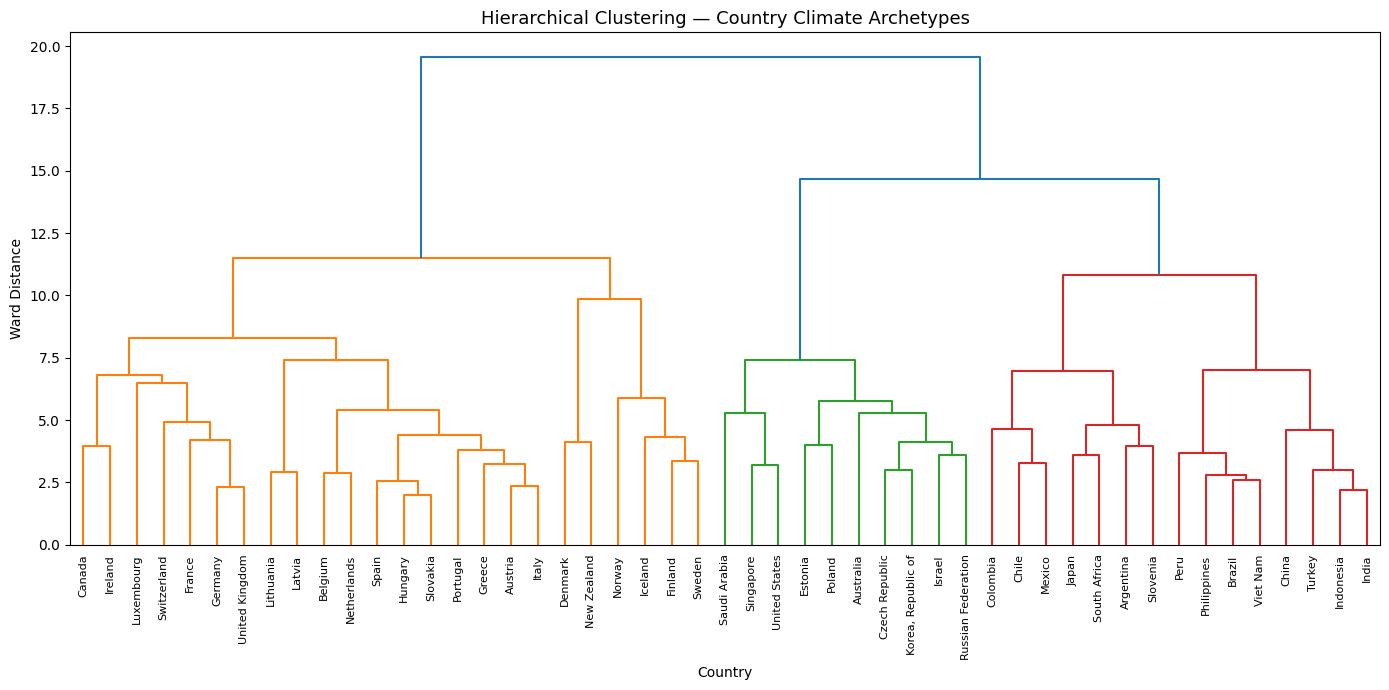

In [6]:
linked = linkage(X_avg, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    labels=ids_avg['Name'].values,
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.title('Hierarchical Clustering — Country Climate Archetypes', fontsize=13)
plt.xlabel('Country')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('outputs/dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
hier_labels = fcluster(linked, K, criterion='maxclust')
hier_score  = silhouette_score(X_avg, hier_labels)

df_avg['hier_cluster'] = hier_labels

print(f"Hierarchical Silhouette Score: {hier_score:.4f}\n")
for i in sorted(df_avg['hier_cluster'].unique()):
    countries = df_avg[df_avg['hier_cluster'] == i]['Name'].sort_values().tolist()
    print(f"  Cluster {i} ({len(countries)}): {', '.join(countries)}")

Hierarchical Silhouette Score: 0.1868

  Cluster 1 (18): Austria, Belgium, Canada, France, Germany, Greece, Hungary, Ireland, Italy, Latvia, Lithuania, Luxembourg, Netherlands, Portugal, Slovakia, Spain, Switzerland, United Kingdom
  Cluster 2 (2): Denmark, New Zealand
  Cluster 3 (4): Finland, Iceland, Norway, Sweden
  Cluster 4 (10): Australia, Czech Republic, Estonia, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia, Singapore, United States
  Cluster 5 (7): Argentina, Chile, Colombia, Japan, Mexico, Slovenia, South Africa
  Cluster 6 (8): Brazil, China, India, Indonesia, Peru, Philippines, Turkey, Viet Nam


### 1c. Cluster Fingerprints

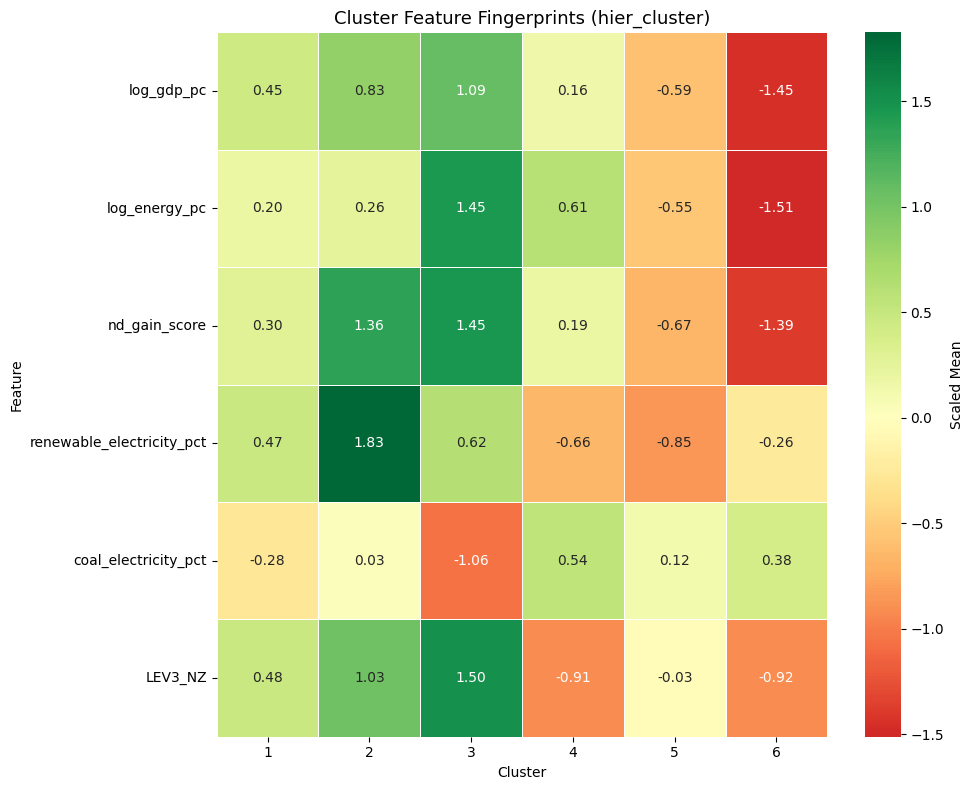

In [8]:
# Choose which method to profile in the heatmap below
PROFILE_METHOD = 'hier_cluster'

# Select a readable subset of features for the heatmap
PROFILE_COLS = [
    'log_gdp_pc', 'log_energy_pc', 'nd_gain_score',
    'renewable_electricity_pct', 'coal_electricity_pct',
    'co2_emissions_per_gdp',
    'LEV1_SEC', 'LEV1_CROSS_SEC', 'LEV1_INT',
    'LEV3_CARBONTAX_E', 'LEV3_ETS_E', 'LEV3_NZ', 'LEV3_NDC',
    'LEV3_RDD_RES', 'LEV3_FFS_E'
]
# Filter to only columns that actually exist in the dataframe
profile_cols = [c for c in PROFILE_COLS if c in df_avg.columns]

profile = df_avg.groupby(PROFILE_METHOD)[profile_cols].mean()

plt.figure(figsize=(10, 8))
sns.heatmap(
    profile.T,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.4,
    cbar_kws={'label': 'Scaled Mean'}
)
plt.title(f'Cluster Feature Fingerprints ({PROFILE_METHOD})', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('outputs/cluster_fingerprints.png', dpi=120, bbox_inches='tight')
plt.show()

### 1d. DBSCAN — Outlier Detection

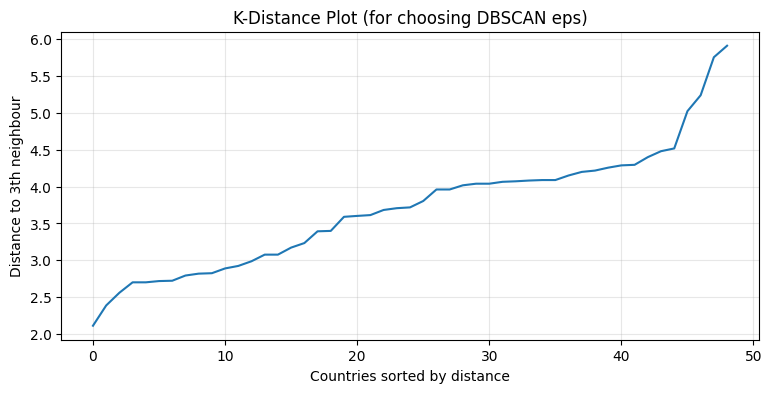

Suggested eps (80th percentile): 4.233


In [9]:
# k-distance plot to estimate eps
MIN_SAMPLES = 3
neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neigh.fit(X_avg)
distances, _ = neigh.kneighbors(X_avg)
kth_distances = np.sort(distances[:, MIN_SAMPLES - 1])

plt.figure(figsize=(9, 4))
plt.plot(kth_distances)
plt.title('K-Distance Plot (for choosing DBSCAN eps)')
plt.ylabel(f'Distance to {MIN_SAMPLES}th neighbour')
plt.xlabel('Countries sorted by distance')
plt.grid(True, alpha=0.3)
plt.show()
print(f"Suggested eps (80th percentile): {np.percentile(kth_distances, 80):.3f}")

In [10]:
# ── Adjust eps based on the plot above ───────────────────────────────────────
DBSCAN_EPS = np.percentile(kth_distances, 80)

db = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_SAMPLES)
db_labels = db.fit_predict(X_avg)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
outliers   = ids_avg['Name'][db_labels == -1].tolist()

print(f"DBSCAN found {n_clusters} cluster(s) with eps={DBSCAN_EPS:.3f}")
print(f"\nOutliers ({len(outliers)}) — countries so distinct they don't fit any cluster:")
for o in sorted(outliers):
    print(f"  • {o}")

DBSCAN found 1 cluster(s) with eps=4.233

Outliers (5) — countries so distinct they don't fit any cluster:
  • Denmark
  • Luxembourg
  • New Zealand
  • Norway
  • Saudi Arabia


### 1e. Stability Check — How reliable are the KMeans clusters?

Runs KMeans 50 times with different seeds and checks how often pairs of countries end up together.
High co-occurrence (>90%) = stable pairing 

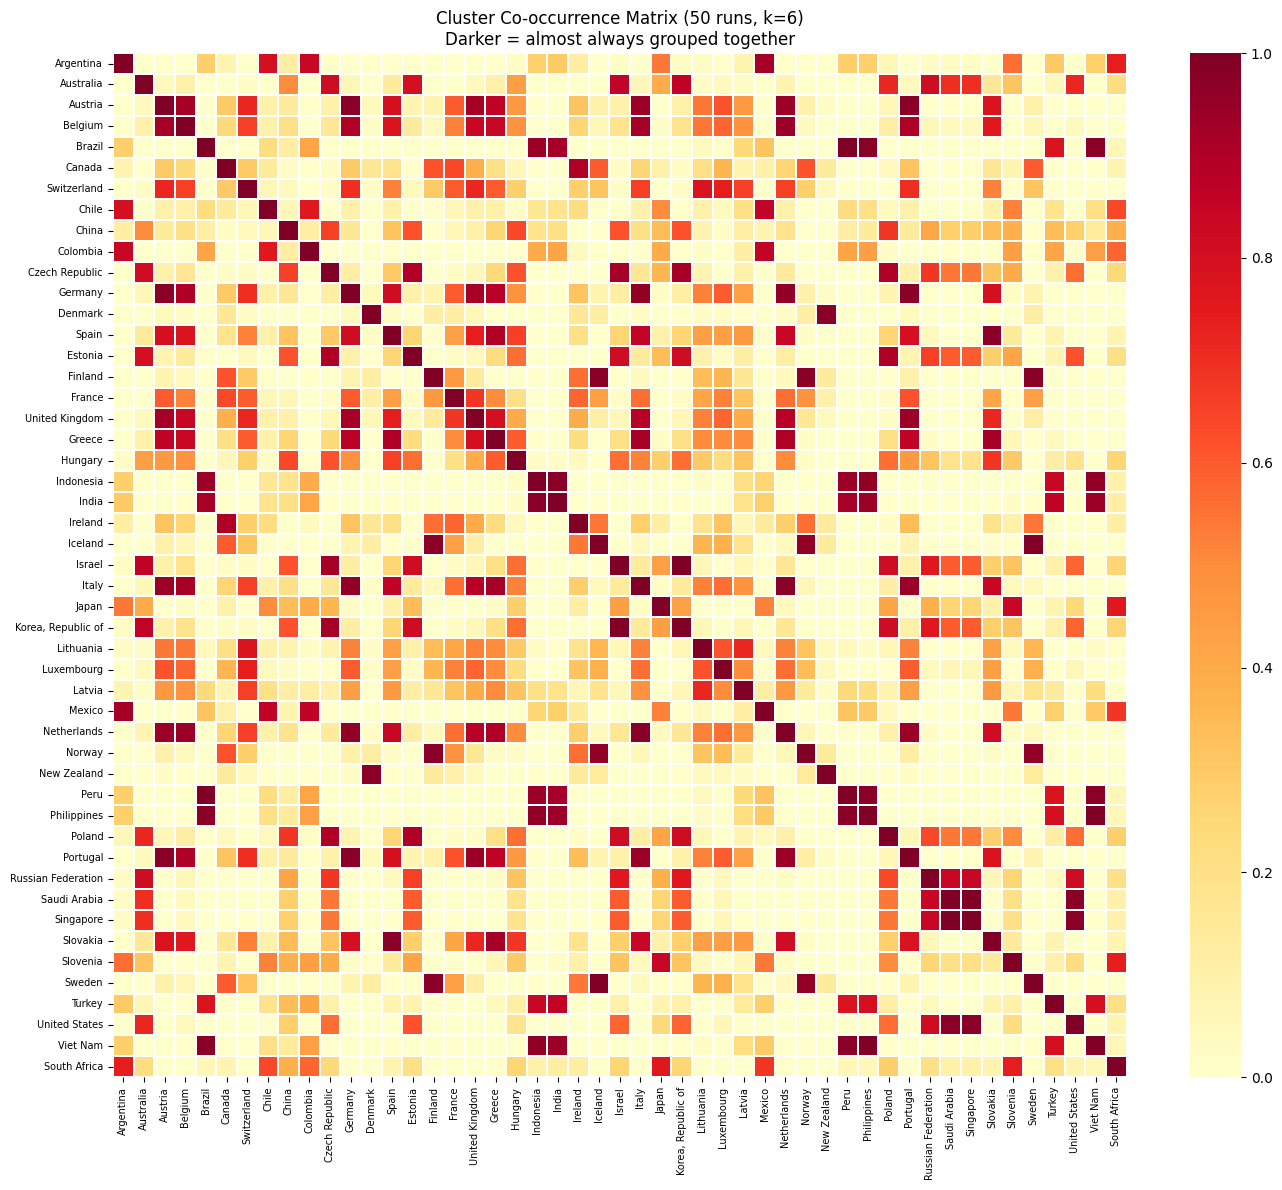


Most stable pairs (co-occurrence > 90%):
  Argentina                 ↔  Mexico                    (92%)
  Austria                   ↔  Belgium                   (92%)
  Austria                   ↔  Germany                   (98%)
  Austria                   ↔  United Kingdom            (92%)
  Austria                   ↔  Italy                     (94%)
  Austria                   ↔  Netherlands               (94%)
  Austria                   ↔  Portugal                  (98%)
  Belgium                   ↔  Italy                     (92%)
  Belgium                   ↔  Netherlands               (94%)
  Brazil                    ↔  Indonesia                 (94%)
  Brazil                    ↔  India                     (92%)
  Brazil                    ↔  Peru                      (100%)
  Brazil                    ↔  Philippines               (98%)
  Brazil                    ↔  Viet Nam                  (98%)
  Czech Republic            ↔  Israel                    (92%)
  Czech Repu

In [11]:
N_RUNS = 50
country_names = ids_avg['Name'].values
n = len(country_names)
co_occurrence = np.zeros((n, n))

for i in range(N_RUNS):
    km_s = KMeans(n_clusters=K, random_state=i, n_init=5)
    labels_s = km_s.fit_predict(X_avg)
    for a in range(n):
        for b in range(n):
            if labels_s[a] == labels_s[b]:
                co_occurrence[a, b] += 1

co_occurrence /= N_RUNS

plt.figure(figsize=(14, 12))
sns.heatmap(
    co_occurrence,
    xticklabels=country_names,
    yticklabels=country_names,
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.2
)
plt.title(f'Cluster Co-occurrence Matrix ({N_RUNS} runs, k={K})\nDarker = almost always grouped together', fontsize=12)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig('outputs/stability_cooccurrence.png', dpi=120, bbox_inches='tight')
plt.show()

# Print most stable pairs
THRESHOLD = 0.90
print(f"\nMost stable pairs (co-occurrence > {THRESHOLD:.0%}):")
printed = set()
for a in range(n):
    for b in range(a + 1, n):
        if co_occurrence[a, b] > THRESHOLD:
            pair = (country_names[a], country_names[b])
            if pair not in printed:
                print(f"  {country_names[a]:<25} ↔  {country_names[b]:<25} ({co_occurrence[a, b]:.0%})")
                printed.add(pair)

---
## Part 2 — Feature Set Comparison: Capacity vs. Effort

Running the same clustering with and without economic indicators.
Interested in Countries whose cluster changes 

In [12]:
# Build policy-only feature set
econ_present   = [c for c in ECON_COLS if c in X_avg.columns]
X_policy_only  = X_avg.drop(columns=econ_present)

print(f"Full feature set:        {X_avg.shape[1]} features")
print(f"Policy-only feature set: {X_policy_only.shape[1]} features")
print(f"Dropped: {econ_present}")

Full feature set:        19 features
Policy-only feature set: 16 features
Dropped: ['log_gdp_pc', 'log_energy_pc', 'nd_gain_score']


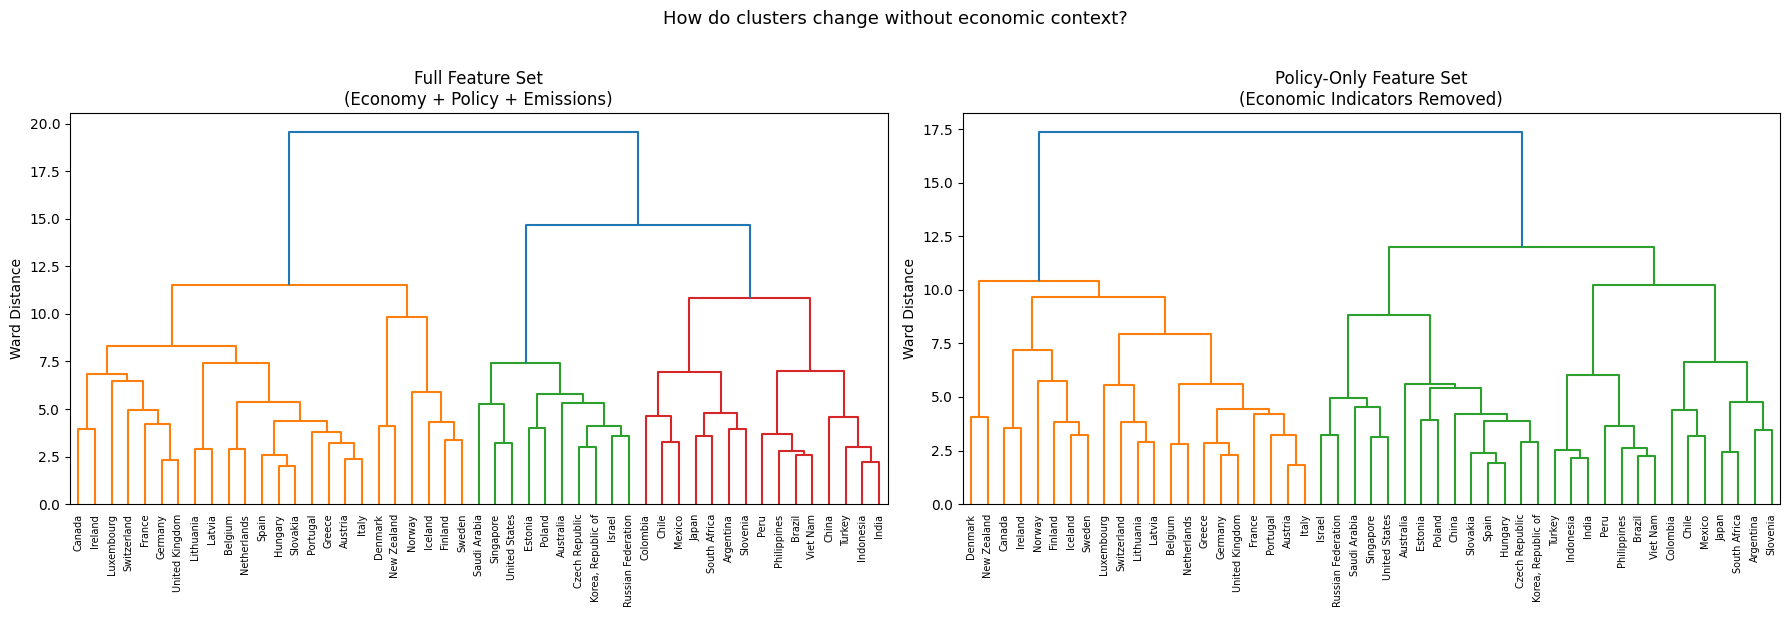

In [13]:
# Run hierarchical on both
linked_full   = linkage(X_avg, method='ward')
linked_policy = linkage(X_policy_only, method='ward')

labels_full   = fcluster(linked_full,   K, criterion='maxclust')
labels_policy = fcluster(linked_policy, K, criterion='maxclust')

# Side-by-side dendrograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

dendrogram(linked_full,   labels=ids_avg['Name'].values, leaf_rotation=90, leaf_font_size=7, ax=ax1)
ax1.set_title('Full Feature Set\n(Economy + Policy + Emissions)')
ax1.set_ylabel('Ward Distance')

dendrogram(linked_policy, labels=ids_avg['Name'].values, leaf_rotation=90, leaf_font_size=7, ax=ax2)
ax2.set_title('Policy-Only Feature Set\n(Economic Indicators Removed)')
ax2.set_ylabel('Ward Distance')

plt.suptitle('How do clusters change without economic context?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/comparison_dendrograms.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# Find countries that switch clusters — the interesting cases
comparison = ids_avg.copy().reset_index(drop=True)
comparison['cluster_full']   = labels_full
comparison['cluster_policy'] = labels_policy
comparison['switched']       = comparison['cluster_full'] != comparison['cluster_policy']

switchers     = comparison[comparison['switched']]
non_switchers = comparison[~comparison['switched']]

print(f"Stable countries ({len(non_switchers)}):")
print(f"  {', '.join(sorted(non_switchers['Name'].tolist()))}\n")

print(f"Countries whose cluster changes when economic indicators are removed ({len(switchers)}):")
print(f"{'Country':<30} {'Full':<10} {'Policy-only':<10}")
print("-" * 50)
for _, row in switchers.sort_values('Name').iterrows():
    print(f"{row['Name']:<30} {row['cluster_full']:<10} {row['cluster_policy']:<10}")

comparison.to_csv('outputs/overperformer_analysis.csv', index=False)
print("\nSaved to outputs/overperformer_analysis.csv")

Stable countries (10):
  Australia, Czech Republic, Estonia, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia, Singapore, United States

Countries whose cluster changes when economic indicators are removed (39):
Country                        Full       Policy-only
--------------------------------------------------
Argentina                      5          6         
Austria                        1          3         
Belgium                        1          3         
Brazil                         6          5         
Canada                         1          2         
Chile                          5          6         
China                          6          4         
Colombia                       5          6         
Denmark                        2          1         
Finland                        3          2         
France                         1          3         
Germany                        1          3         
Greece                     

---
## Part 3 — Autoencoder Experiments (averaged data)

Compressing the data to 3D using a neural autoencoder, then clustering in that latent space.
The higher silhouette score suggests the AE is finding non-linear structure that PCA/hierarchical miss.

  Epoch [100/500] Loss: 0.3023
  Epoch [200/500] Loss: 0.1406
  Epoch [300/500] Loss: 0.0821
  Epoch [400/500] Loss: 0.0611
  Epoch [500/500] Loss: 0.0506


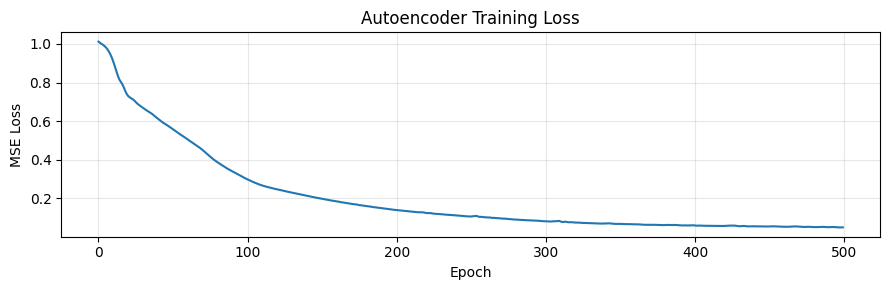

In [15]:
if not TORCH_AVAILABLE:
    print("Skipping — PyTorch not available.")
else:
    class ClimateAE(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 32), nn.ReLU(),
                nn.Linear(32, 16),        nn.ReLU(),
                nn.Linear(16, 3)
            )
            self.decoder = nn.Sequential(
                nn.Linear(3, 16),          nn.ReLU(),
                nn.Linear(16, 32),         nn.ReLU(),
                nn.Linear(32, input_dim)
            )
        def forward(self, x):
            latent  = self.encoder(x)
            decoded = self.decoder(latent)
            return latent, decoded

    torch.manual_seed(SEED)
    X_tensor   = torch.FloatTensor(X_avg.values)
    input_dim  = X_avg.shape[1]
    model      = ClimateAE(input_dim)
    optimizer  = optim.Adam(model.parameters(), lr=AE_LR)
    criterion  = nn.MSELoss()

    # Save column order so we can use it for the counterfactual section
    FEATURE_COLS = list(X_avg.columns)

    losses = []
    for epoch in range(AE_EPOCHS):
        model.train()
        latent, decoded = model(X_tensor)
        loss = criterion(decoded, X_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{AE_EPOCHS}] Loss: {loss.item():.4f}")

    plt.figure(figsize=(9, 3))
    plt.plot(losses)
    plt.title('Autoencoder Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/ae_loss.png', dpi=120, bbox_inches='tight')
    plt.show()

In [16]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    model.eval()
    with torch.no_grad():
        X_latent, _ = model(X_tensor)
        X_latent = X_latent.numpy()

    # KMeans in latent space
    km_ae     = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    ae_labels = km_ae.fit_predict(X_latent)
    ae_score  = silhouette_score(X_latent, ae_labels)

    df_avg['ae_cluster'] = ae_labels

    print(f"AE+KMeans Silhouette Score: {ae_score:.4f}\n")
    for i in range(K):
        countries = df_avg[df_avg['ae_cluster'] == i]['Name'].sort_values().tolist()
        print(f"  Archetype {i} ({len(countries)}): {', '.join(countries)}")

    # 3D interactive plot
    df_viz = pd.DataFrame(X_latent, columns=['Latent_1', 'Latent_2', 'Latent_3'])
    df_viz['Country'] = ids_avg['Name'].values
    df_viz['Cluster'] = ae_labels.astype(str)

    fig = px.scatter_3d(
        df_viz, x='Latent_1', y='Latent_2', z='Latent_3',
        color='Cluster', hover_name='Country',
        title=f'AE Latent Space — Silhouette: {ae_score:.3f}',
        template='plotly_dark', opacity=0.85
    )
    fig.write_html('outputs/ae_latent_3d.html')
    fig.show()
    print("\nInteractive 3D plot saved to outputs/ae_latent_3d.html")

AE+KMeans Silhouette Score: 0.3514

  Archetype 0 (11): Argentina, Chile, Greece, Ireland, Japan, Latvia, Lithuania, Mexico, Norway, Slovenia, Spain
  Archetype 1 (9): Austria, Canada, France, Germany, Italy, Netherlands, Portugal, Switzerland, United Kingdom
  Archetype 2 (8): Brazil, Colombia, India, Indonesia, Peru, Philippines, Turkey, Viet Nam
  Archetype 3 (5): Denmark, Finland, Iceland, New Zealand, Sweden
  Archetype 4 (3): Belgium, Luxembourg, Saudi Arabia
  Archetype 5 (13): Australia, China, Czech Republic, Estonia, Hungary, Israel, Korea, Republic of, Poland, Russian Federation, Singapore, Slovakia, South Africa, United States



Interactive 3D plot saved to outputs/ae_latent_3d.html


### 3b. Counterfactual Test

Take a country's real scaled data, manually adjust specific features, and see if the model moves it to a different cluster.
This tests whether the latent space is *meaningful* 

In [23]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    # ── CONFIG — change this to test different countries/scenarios ────────────
    TEST_COUNTRY = 'AUS'   # ISO3 code

    # Feature tweaks (these are scaled values)
    TWEAKS = {
    'coal_electricity_pct':       -4.0,
    'renewable_electricity_pct':   4.0,
    'log_energy_pc':              -3.0,
    'LEV3_CARBONTAX_E':            3.0,  
    'LEV3_ETS_E':                  3.0,
    'LEV3_NZ':                     3.0,
}
    # ─────────────────────────────────────────────────────────────────────────

    country_names_arr = ids_avg['country_code'].values
    idx = np.where(country_names_arr == TEST_COUNTRY)[0]

    if len(idx) == 0:
        print(f"Country '{TEST_COUNTRY}' not found. Available: {list(country_names_arr)}")
    else:
        idx = idx[0]
        country_display = ids_avg.iloc[idx]['Name']

        # Original
        original = X_avg.iloc[idx].copy()
        synthetic = original.copy()

        for feature, value in TWEAKS.items():
            if feature in synthetic.index:
                synthetic[feature] = value
            else:
                print(f"[Warning] Feature '{feature}' not in dataset — skipping.")

        # Enforce column order matches what the model was trained on
        synthetic = synthetic[FEATURE_COLS]
        original  = original[FEATURE_COLS]

        with torch.no_grad():
            orig_tensor  = torch.FloatTensor(original.values).unsqueeze(0)
            synth_tensor = torch.FloatTensor(synthetic.values).unsqueeze(0)
            latent_orig,  _ = model(orig_tensor)
            latent_synth, _ = model(synth_tensor)

        orig_cluster  = km_ae.predict(latent_orig.numpy())[0]
        synth_cluster = km_ae.predict(latent_synth.numpy())[0]
        distance      = torch.norm(latent_orig - latent_synth).item()

        print(f"Country: {country_display}")
        print(f"Original Cluster:   {orig_cluster}")
        print(f"Synthetic Cluster:  {synth_cluster}")
        print(f"Distance moved in latent space: {distance:.4f}")

        if orig_cluster == synth_cluster:
            print(f"\nResult: Still in Archetype {orig_cluster} — tweaks not large enough to cross a boundary.")
            print("Check distances to other cluster centres below:")
        else:
            print(f"\nResult: Moved from Archetype {orig_cluster} → Archetype {synth_cluster}!")

        print("\nDistances to each cluster centre:")
        for i, center in enumerate(km_ae.cluster_centers_):
            d = np.linalg.norm(latent_synth.numpy() - center)
            marker = " ← assigned" if i == synth_cluster else ""
            print(f"  Archetype {i}: {d:.4f}{marker}")

[Warning] Feature 'LEV3_CARBONTAX_E' not in dataset — skipping.
[Warning] Feature 'LEV3_ETS_E' not in dataset — skipping.
Country: Australia
Original Cluster:   5
Synthetic Cluster:  1
Distance moved in latent space: 4.6544

Result: Moved from Archetype 5 → Archetype 1!

Distances to each cluster centre:
  Archetype 0: 9.8517
  Archetype 1: 4.6426 ← assigned
  Archetype 2: 22.2625
  Archetype 3: 18.7314
  Archetype 4: 14.9687
  Archetype 5: 8.8263


---
## Part 4 — Temporal Trajectories

Using the full time-series dataset (country-year pairs) to see how countries have *moved* through archetype space from 2000 to the present.

In [18]:
if not TORCH_AVAILABLE:
    print("Skipping — PyTorch required for trajectory AE.")
else:
    class ClimateTrajectoryAE(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 32), nn.ReLU(),
                nn.Linear(32, 16),        nn.ReLU(),
                nn.Linear(16, 3)
            )
            self.decoder = nn.Sequential(
                nn.Linear(3, 16),          nn.ReLU(),
                nn.Linear(16, 32),         nn.ReLU(),
                nn.Linear(32, input_dim)
            )
        def forward(self, x):
            latent  = self.encoder(x)
            decoded = self.decoder(latent)
            return latent, decoded

    torch.manual_seed(SEED)
    X_temp_tensor = torch.FloatTensor(X_temp.values)
    traj_model    = ClimateTrajectoryAE(X_temp.shape[1])
    traj_optimizer = optim.Adam(traj_model.parameters(), lr=AE_LR)
    traj_criterion = nn.MSELoss()

    TRAJ_EPOCHS = AE_EPOCHS
    traj_losses = []
    for epoch in range(TRAJ_EPOCHS):
        latent, decoded = traj_model(X_temp_tensor)
        loss = traj_criterion(decoded, X_temp_tensor)
        traj_optimizer.zero_grad()
        loss.backward()
        traj_optimizer.step()
        traj_losses.append(loss.item())
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{TRAJ_EPOCHS}] Loss: {loss.item():.4f}")

    print("Trajectory AE trained.")

  Epoch [100/500] Loss: 0.2682
  Epoch [200/500] Loss: 0.1696
  Epoch [300/500] Loss: 0.1430
  Epoch [400/500] Loss: 0.1307
  Epoch [500/500] Loss: 0.1209
Trajectory AE trained.


In [19]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    traj_model.eval()
    with torch.no_grad():
        traj_latent, _ = traj_model(X_temp_tensor)
        traj_latent = traj_latent.numpy()

    # Cluster the trajectory points
    km_traj     = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    traj_labels = km_traj.fit_predict(traj_latent)
    traj_score  = silhouette_score(traj_latent, traj_labels)
    print(f"Trajectory Silhouette Score: {traj_score:.4f}")

    df_viz = pd.DataFrame(traj_latent, columns=['Dim1', 'Dim2', 'Dim3'])
    df_viz = pd.concat([ids_temp.reset_index(drop=True), df_viz], axis=1)
    df_viz['state_cluster'] = traj_labels
    df_viz = df_viz.sort_values(['country_code', 'year'])

    # 3D snake plot — each country traces its path through the latent space
    fig = px.line_3d(
        df_viz, x='Dim1', y='Dim2', z='Dim3',
        color='country_code',
        line_group='country_code',
        hover_name='Name',
        hover_data=['year'],
        title='20-Year Climate Action Trajectories (AE Latent Space)',
        template='plotly_dark'
    )
    fig.write_html('outputs/trajectories_3d.html')
    fig.show()
    print("Interactive trajectory plot saved to outputs/trajectories_3d.html")

Trajectory Silhouette Score: 0.3750


Interactive trajectory plot saved to outputs/trajectories_3d.html


In [20]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    # Print cluster sequence for each country — shows stability or transitions
    print("Country Climate Trajectories (cluster sequence per year)\n")
    print(f"{'Country':<25} Sequence")
    print("-" * 80)

    for country in df_viz['Name'].unique():
        seq = df_viz[df_viz['Name'] == country]['state_cluster'].tolist()
        path_str = " → ".join(map(str, seq))
        # Highlight countries that changed cluster
        changed = len(set(seq)) > 1
        marker  = " ★" if changed else ""
        print(f"{country:<25} {path_str}{marker}")

    print("\n★ = country changed cluster at least once")

Country Climate Trajectories (cluster sequence per year)

Country                   Sequence
--------------------------------------------------------------------------------
Argentina                 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 2 → 2 → 2 ★
Australia                 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0
Austria                   0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 4 → 1 → 1 → 1 → 1 ★
Belgium                   0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 1 → 1 → 1 → 1 ★
Brazil                    3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3
Canada                    0 → 0 → 0 → 0 → 0 → 0 → 0 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 → 2 ★
Switzerland               4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 4 → 1 → 1 → 1 → 1 ★
Chile                     3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 → 3 

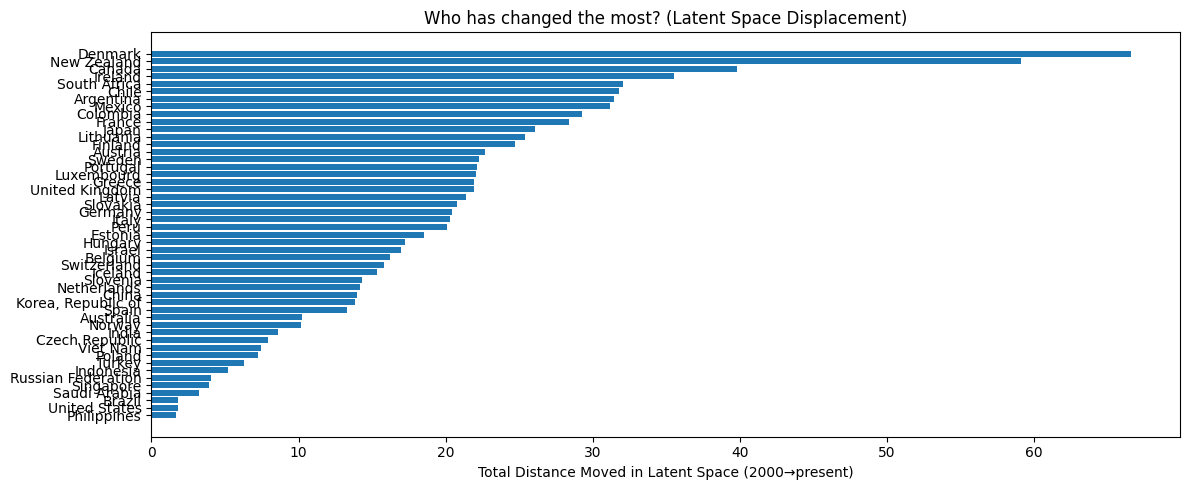

Top structural jumps detected (top 5% of year-over-year movement):
        Name  year  dist_moved  state_cluster
     Denmark  2020   40.673527              5
 New Zealand  2018   39.966335              5
    Colombia  2017   21.898842              2
South Africa  2019   18.764025              2
   Argentina  2018   18.725979              2
       Japan  2012   17.903038              2
      Canada  2007   17.319860              2
     Ireland  2010   17.188812              2
  Luxembourg  2017   15.492987              1
      Mexico  2014   15.288334              2


In [21]:
if not TORCH_AVAILABLE:
    print("Skipping.")
else:
    # Distance moved year-over-year — who is accelerating?
    df_viz['dist_moved'] = (
        df_viz.groupby('country_code')
        .apply(lambda x: np.sqrt(
            x['Dim1'].diff()**2 + x['Dim2'].diff()**2 + x['Dim3'].diff()**2
        ))
        .reset_index(level=0, drop=True)
    )

    # Total distance moved per country over the full period
    total_movement = (
        df_viz.groupby('Name')['dist_moved']
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    total_movement.columns = ['Country', 'Total Distance Moved']

    plt.figure(figsize=(12, 5))
    plt.barh(total_movement['Country'][::-1], total_movement['Total Distance Moved'][::-1])
    plt.xlabel('Total Distance Moved in Latent Space (2000→present)')
    plt.title('Who has changed the most? (Latent Space Displacement)')
    plt.tight_layout()
    plt.savefig('outputs/total_movement.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Top structural jumps — largest single-year moves
    threshold = df_viz['dist_moved'].quantile(0.95)
    top_jumps = (
        df_viz[df_viz['dist_moved'] > threshold]
        [['Name', 'year', 'dist_moved', 'state_cluster']]
        .sort_values('dist_moved', ascending=False)
        .head(10)
    )
    print("Top structural jumps detected (top 5% of year-over-year movement):")
    print(top_jumps.to_string(index=False))

---
## Summary — Silhouette Scores Across Methods

In [22]:
scores = {
    'KMeans (full)':        km_score,
    'Hierarchical (full)':  hier_score,
}

if TORCH_AVAILABLE:
    scores['AE + KMeans (averaged)'] = ae_score
    scores['AE + KMeans (temporal)'] = traj_score

print(f"{'Method':<35} {'Silhouette Score':>16}")
print("-" * 53)
for method, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"{method:<35} {score:>16.4f}")

Method                              Silhouette Score
-----------------------------------------------------
AE + KMeans (temporal)                        0.3750
AE + KMeans (averaged)                        0.3514
Hierarchical (full)                           0.1868
KMeans (full)                                 0.1864
